In [1]:
# Standard Libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch

# Scikit-Learn
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Statsmodels and Scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr

from tqdm import tqdm  # For progress tracking

import random

# Suppress warnings
warnings.filterwarnings('ignore')

In [2]:
def winsorize_data(train_df, val_df, columns):
    """
    Winsorizes the specified columns in both training and validation DataFrames
    using the 0.5% and 99.5% quantiles from the training set.
    """
    for col in columns:
        lower = train_df[col].quantile(0.005)
        upper = train_df[col].quantile(0.995)

        # Use .loc to avoid chained assignment issues
        train_df.loc[:, col] = train_df[col].clip(lower, upper)
        val_df.loc[:, col] = val_df[col].clip(lower, upper)

    return train_df, val_df


def evaluate_metrics(y_true, y_pred, label="Validation"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    pearson_corr, _ = pearsonr(y_true.ravel(), y_pred.ravel())
    spearman_corr, _ = spearmanr(y_true.ravel(), y_pred.ravel())
    
    print(f"  [{label}] MAE: {mae:.4f}")
    print(f"  [{label}] RMSE: {rmse:.4f}")
    print(f"  [{label}] Pearson Correlation: {pearson_corr:.4f}")
    print(f"  [{label}] Spearman Correlation: {spearman_corr:.4f}")
    
def set_all_seeds(seed: int):
    """
    Sets the random seeds for Python's random module, NumPy, and PyTorch.

    Args:
        seed: The seed value to use.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)  # For multi-GPU
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_all_seeds(42)

In [3]:
# Load main dataset and VIX
data = pd.read_parquet('processed_dataset.parquet')
vix = pd.read_csv('data/VIX/VIX_History.csv')

# Convert VIX DATE to datetime
vix['DATE'] = pd.to_datetime(vix['DATE'], errors='coerce')

# Calculate log returns and squared returns
vix['return'] = np.log(vix['CLOSE'] / vix['CLOSE'].shift(1))
vix['log_return_squared'] = vix['return'].pow(2)

# Realized vol (log of rolling sum of squared log returns)
EPS = 1e-8
vix['VIX_RV_10d'] = np.log(vix['log_return_squared'].rolling(window=10).sum() + EPS)
vix['VIX_RV_5d']  = np.log(vix['log_return_squared'].rolling(window=5).sum() + EPS)
vix['VIX_RV_1d']  = np.log(vix['log_return_squared'].rolling(window=1).sum() + EPS)

# Drop rows with missing VIX RV
vix = vix.dropna(subset=['VIX_RV_10d', 'VIX_RV_5d', 'VIX_RV_1d'])

# Convert 'date' in main data to datetime
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')

# Merge VIX RVs
data = pd.merge(data, vix[['DATE', 'VIX_RV_10d', 'VIX_RV_5d', 'VIX_RV_1d']],
                left_on='date', right_on='DATE', how='left').drop(columns=['DATE'])

# --- Feature Engineering ---
rv_cols_10 = [col for col in data.columns if '10min_RV' in col]
rv_cols_30 = [col for col in data.columns if '30min_RV' in col]
rv_cols_65 = [col for col in data.columns if '65min_RV' in col]

rv_cols = rv_cols_10 + rv_cols_30 + rv_cols_65

# Lagged target
# Make sure the data is sorted by symbol and then by date
data = data.sort_values(['symbol', 'date']).reset_index(drop=True)

# Initialize the new column with NaN values
data['prev_day_market_rv'] = np.nan

# Iterate through each unique ticker
for ticker in data['symbol'].unique():
    # Select data for the current ticker
    ticker_data = data[data['symbol'] == ticker].copy()

    # Shift the 'next_day_market_rv' column by one within the ticker's data
    ticker_data['prev_day_market_rv'] = ticker_data['next_day_market_rv'].shift(1)

    # Update the main dataframe with the shifted values for the current ticker
    data.loc[data['symbol'] == ticker, 'prev_day_market_rv'] = ticker_data['prev_day_market_rv']
    

# Rolling statistics of 15m RVs (per day)
data['market_rv_10m_mean']  = data[rv_cols_10].mean(axis=1)
data['market_rv_10m_std']   = data[rv_cols_10].std(axis=1)
data['market_rv_10m_max']   = data[rv_cols_10].max(axis=1)
data['market_rv_10m_min']   = data[rv_cols_10].min(axis=1)
data['market_rv_10m_range'] = data['market_rv_10m_max'] - data['market_rv_10m_min']
data['market_rv_10m_skew']  = data[rv_cols_10].skew(axis=1)

data['market_rv_30m_mean']  = data[rv_cols_30].mean(axis=1)
data['market_rv_30m_std']   = data[rv_cols_30].std(axis=1)
data['market_rv_30m_max']   = data[rv_cols_30].max(axis=1)
data['market_rv_30m_min']   = data[rv_cols_30].min(axis=1)
data['market_rv_30m_range'] = data['market_rv_30m_max'] - data['market_rv_30m_min']
data['market_rv_30m_skew']  = data[rv_cols_30].skew(axis=1)

data['market_rv_65m_mean']  = data[rv_cols_30].mean(axis=1)
data['market_rv_65m_std']   = data[rv_cols_30].std(axis=1)
data['market_rv_65m_max']   = data[rv_cols_30].max(axis=1)
data['market_rv_65m_min']   = data[rv_cols_30].min(axis=1)
data['market_rv_65m_range'] = data['market_rv_30m_max'] - data['market_rv_30m_min']
data['market_rv_65m_skew']  = data[rv_cols_30].skew(axis=1)

# Final feature and target columns
feature_cols = rv_cols + [
    'VIX_RV_10d', 'VIX_RV_5d', 'VIX_RV_1d',
    'market_rv_10m_mean', 'market_rv_10m_std', 'market_rv_10m_max',
    'market_rv_10m_min', 'market_rv_10m_range', 'market_rv_10m_skew',
    'market_rv_30m_mean', 'market_rv_30m_std', 'market_rv_30m_max',
    'market_rv_30m_min', 'market_rv_30m_range', 'market_rv_30m_skew',
    'market_rv_30m_mean', 'market_rv_30m_std', 'market_rv_30m_max',
    'market_rv_30m_min', 'market_rv_30m_range', 'market_rv_30m_skew',
    'prev_day_market_rv'
] 


target_cols = ['next_day_rv'] # next_day_market_rv

# Drop any rows with missing values introduced by lagging/rolling
data = data[['date'] + ['symbol'] + feature_cols + target_cols].dropna().reset_index(drop=True)

data.head()

,date,symbol,10min_RV_09:30:00,10min_RV_09:45:00,10min_RV_10:00:00,10min_RV_10:15:00,10min_RV_10:30:00,10min_RV_10:45:00,10min_RV_11:00:00,10min_RV_11:15:00,...,market_rv_30m_range,market_rv_30m_skew,market_rv_30m_mean,market_rv_30m_std,market_rv_30m_max,market_rv_30m_min,market_rv_30m_range,market_rv_30m_skew,prev_day_market_rv,next_day_rv
0,2015-04-20,AAPL,2.075253,3.939965,2.749876,1.781785,3.304716,2.277270,1.892359,2.768116,...,1.574694,0.303743,4.080034,0.513337,5.025834,3.451140,1.574694,0.303743,-8.871891,-9.331343
1,2015-04-21,AAPL,3.872803,2.576954,3.777390,4.245680,2.867653,3.812691,3.568979,4.045871,...,1.619199,0.245304,4.075404,0.481810,5.013373,3.394174,1.619199,0.245304,-8.943237,-9.196481
2,2015-04-22,AAPL,4.124072,2.684795,2.432164,4.044498,2.705646,2.602531,2.541775,2.575101,...,1.541754,0.382363,4.058415,0.521160,4.946052,3.404298,1.541754,0.382363,-8.793295,-9.021707
3,2015-04-23,AAPL,4.111218,2.873448,3.113546,0.591142,3.656741,1.478575,4.180749,2.002689,...,1.748538,0.448262,4.041920,0.544274,5.168973,3.420435,1.748538,0.448262,-8.865164,-9.246610
4,2015-04-24,AAPL,1.406464,2.720797,4.008735,4.199466,4.123232,3.457066,3.871265,4.059983,...,1.481130,0.315716,4.069844,0.522798,4.951240,3.470110,1.481130,0.315716,-8.904154,-8.781436


In [4]:
dates = data['date'].unique()
dates = np.sort(dates)  # Sort the dates using numpy's sort function

test_size = int(len(dates) * 0.1)
test_dates = dates[-test_size:]  # Last 20% as test set
train_dates = dates[:-test_size]

# Split the data
train_val_df = data[data['date'].isin(train_dates)].copy().reset_index(drop=True)
test_df = data[data['date'].isin(test_dates)].copy().reset_index(drop=True)

print(f"Train/Val date range: {train_val_df['date'].min()} to {train_val_df['date'].max()}, n={len(train_dates)}")
print(f"Test date range: {test_df['date'].min()} to {test_df['date'].max()}, n={len(test_dates)}")

Train/Val date range: 2015-04-20 00:00:00 to 2024-04-10 00:00:00, n=2260
Test date range: 2024-04-11 00:00:00 to 2025-04-10 00:00:00, n=251


In [5]:
train_val_df.columns

Index(['date', 'symbol', '10min_RV_09:30:00', '10min_RV_09:45:00',
       '10min_RV_10:00:00', '10min_RV_10:15:00', '10min_RV_10:30:00',
       '10min_RV_10:45:00', '10min_RV_11:00:00', '10min_RV_11:15:00',
       ...
       'market_rv_30m_range', 'market_rv_30m_skew', 'market_rv_30m_mean',
       'market_rv_30m_std', 'market_rv_30m_max', 'market_rv_30m_min',
       'market_rv_30m_range', 'market_rv_30m_skew', 'prev_day_market_rv',
       'next_day_rv'],
      dtype='object', length=187)

In [6]:
# CV
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
all_dates = np.unique(train_val_df['date'])
all_fold_results = []

print("LASSO REGRESSION")

for fold, (date_train_index, date_val_index) in enumerate(tscv.split(all_dates)):
    print(f"\n=== Fold {fold+1} ===")

    train_dates = all_dates[date_train_index]
    val_dates = all_dates[date_val_index]
    
    train_mask = train_val_df['date'].isin(train_dates)
    val_mask = train_val_df['date'].isin(val_dates)
    
    train_df = train_val_df[train_mask].copy()
    val_df = train_val_df[val_mask].copy()

    train_features = train_df[feature_cols]
    val_features = val_df[feature_cols]
    train_target = train_df[target_cols]
    val_target = val_df[target_cols]

    # Scaling
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(train_features)
    y_train_scaled = scaler_y.fit_transform(train_target)
    X_val_scaled = scaler_X.transform(val_features)
    y_val_scaled = scaler_y.transform(val_target)

    # Model
    model = Lasso(alpha=0.01)
    print("  Train shape:", X_train_scaled.shape)

    model.fit(X_train_scaled, y_train_scaled)

    # Predict and inverse transform
    y_train_pred = scaler_y.inverse_transform(model.predict(X_train_scaled).reshape(-1, 1))
    y_val_pred = scaler_y.inverse_transform(model.predict(X_val_scaled).reshape(-1, 1))
    y_train_true = scaler_y.inverse_transform(y_train_scaled)
    y_val_true = scaler_y.inverse_transform(y_val_scaled)

    r2_train = r2_score(y_train_true, y_train_pred)
    r2_val = r2_score(y_val_true, y_val_pred)

    print(f"  Train R-squared: {r2_train:.4f}")
    print(f"  Validation R-squared: {r2_val:.4f}")
    evaluate_metrics(y_train_true, y_train_pred, label="Train")
    evaluate_metrics(y_val_true, y_val_pred, label="Validation")

    all_fold_results.append({
        'fold': fold + 1,
        'train_r2': r2_train,
        'val_r2': r2_val,
    })

print("\n=== Summary of all folds ===")
for result in all_fold_results:
    print(f"Fold {result['fold']}: Train R² = {result['train_r2']:.4f}, Validation R² = {result['val_r2']:.4f}")

LASSO REGRESSION

=== Fold 1 ===
  Train shape: (35079, 196)
  Train R-squared: 0.2058
  Validation R-squared: 0.1101
  [Train] MAE: 0.7576
  [Train] RMSE: 0.9756
  [Train] Pearson Correlation: 0.4546
  [Train] Spearman Correlation: 0.4449
  [Validation] MAE: 0.7610
  [Validation] RMSE: 0.9983
  [Validation] Pearson Correlation: 0.3761
  [Validation] Spearman Correlation: 0.3223

=== Fold 2 ===
  Train shape: (70082, 196)
  Train R-squared: 0.1893
  Validation R-squared: 0.1214
  [Train] MAE: 0.7622
  [Train] RMSE: 0.9795
  [Train] Pearson Correlation: 0.4355
  [Train] Spearman Correlation: 0.4128
  [Validation] MAE: 0.7242
  [Validation] RMSE: 0.9228
  [Validation] Pearson Correlation: 0.3489
  [Validation] Spearman Correlation: 0.3372

=== Fold 3 ===
  Train shape: (105774, 196)
  Train R-squared: 0.1816
  Validation R-squared: 0.3509
  [Train] MAE: 0.7486
  [Train] RMSE: 0.9606
  [Train] Pearson Correlation: 0.4265
  [Train] Spearman Correlation: 0.4201
  [Validation] MAE: 0.7607
  

In [7]:
# CV
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
all_dates = np.unique(train_val_df['date'])
all_fold_results = []

print("LASSO REGRESSION")

for fold, (date_train_index, date_val_index) in enumerate(tscv.split(all_dates)):
    print(f"\n=== Fold {fold+1} ===")

    train_dates = all_dates[date_train_index]
    val_dates = all_dates[date_val_index]
    
    train_mask = train_val_df['date'].isin(train_dates)
    val_mask = train_val_df['date'].isin(val_dates)
    
    train_df = train_val_df[train_mask].copy()
    val_df = train_val_df[val_mask].copy()
    
    # --- Encode symbol as one-hot features ---
    train_symbol_dummies = pd.get_dummies(train_df['symbol'], prefix='symbol')
    val_symbol_dummies = pd.get_dummies(val_df['symbol'], prefix='symbol')
    
    # Align columns between training and validation sets
    train_symbol_dummies, val_symbol_dummies = train_symbol_dummies.align(val_symbol_dummies, 
                                                                          join='outer', axis=1, fill_value=0)
    
    # Combine numeric features with symbol dummies
    train_features = pd.concat([train_df[feature_cols], train_symbol_dummies], axis=1)
    val_features = pd.concat([val_df[feature_cols], val_symbol_dummies], axis=1)
    
    train_target = train_df[target_cols]
    val_target = val_df[target_cols]

    # Scaling
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(train_features)
    y_train_scaled = scaler_y.fit_transform(train_target)
    X_val_scaled = scaler_X.transform(val_features)
    y_val_scaled = scaler_y.transform(val_target)

    # Model
    model = Lasso(alpha=0.01)
    print("  Train shape:", X_train_scaled.shape)

    model.fit(X_train_scaled, y_train_scaled)

    # Predict and inverse transform
    y_train_pred = scaler_y.inverse_transform(model.predict(X_train_scaled).reshape(-1, 1))
    y_val_pred = scaler_y.inverse_transform(model.predict(X_val_scaled).reshape(-1, 1))
    y_train_true = scaler_y.inverse_transform(y_train_scaled)
    y_val_true = scaler_y.inverse_transform(y_val_scaled)

    r2_train = r2_score(y_train_true, y_train_pred)
    r2_val = r2_score(y_val_true, y_val_pred)

    print(f"  Train R-squared: {r2_train:.4f}")
    print(f"  Validation R-squared: {r2_val:.4f}")
    evaluate_metrics(y_train_true, y_train_pred, label="Train")
    evaluate_metrics(y_val_true, y_val_pred, label="Validation")
    
    # Store results for plotting per ticker
    val_df['y_true'] = y_val_true
    val_df['y_pred'] = y_val_pred

    all_fold_results.append({
        'fold': fold + 1,
        'train_r2': r2_train,
        'val_r2': r2_val,
        'train_dates': train_dates,
        'val_dates': val_dates,
        'val_df': val_df[['date', 'symbol', 'y_true', 'y_pred']].copy() 
    })

print("\n=== Summary of all folds ===")
for result in all_fold_results:
    print(f"Fold {result['fold']}: Train R² = {result['train_r2']:.4f}, Validation R² = {result['val_r2']:.4f}")


LASSO REGRESSION

=== Fold 1 ===
  Train shape: (35079, 290)
  Train R-squared: 0.4470
  Validation R-squared: 0.3103
  [Train] MAE: 0.6180
  [Train] RMSE: 0.8141
  [Train] Pearson Correlation: 0.6713
  [Train] Spearman Correlation: 0.6658
  [Validation] MAE: 0.6545
  [Validation] RMSE: 0.8788
  [Validation] Pearson Correlation: 0.5868
  [Validation] Spearman Correlation: 0.5704

=== Fold 2 ===
  Train shape: (70082, 292)
  Train R-squared: 0.4099
  Validation R-squared: 0.3018
  [Train] MAE: 0.6370
  [Train] RMSE: 0.8357
  [Train] Pearson Correlation: 0.6424
  [Train] Spearman Correlation: 0.6331
  [Validation] MAE: 0.6315
  [Validation] RMSE: 0.8226
  [Validation] Pearson Correlation: 0.5503
  [Validation] Spearman Correlation: 0.5494

=== Fold 3 ===
  Train shape: (105774, 294)
  Train R-squared: 0.3928
  Validation R-squared: 0.4238
  [Train] MAE: 0.6333
  [Train] RMSE: 0.8274
  [Train] Pearson Correlation: 0.6291
  [Train] Spearman Correlation: 0.6269
  [Validation] MAE: 0.7095
  


=== Visualizing Predictions per Ticker ===


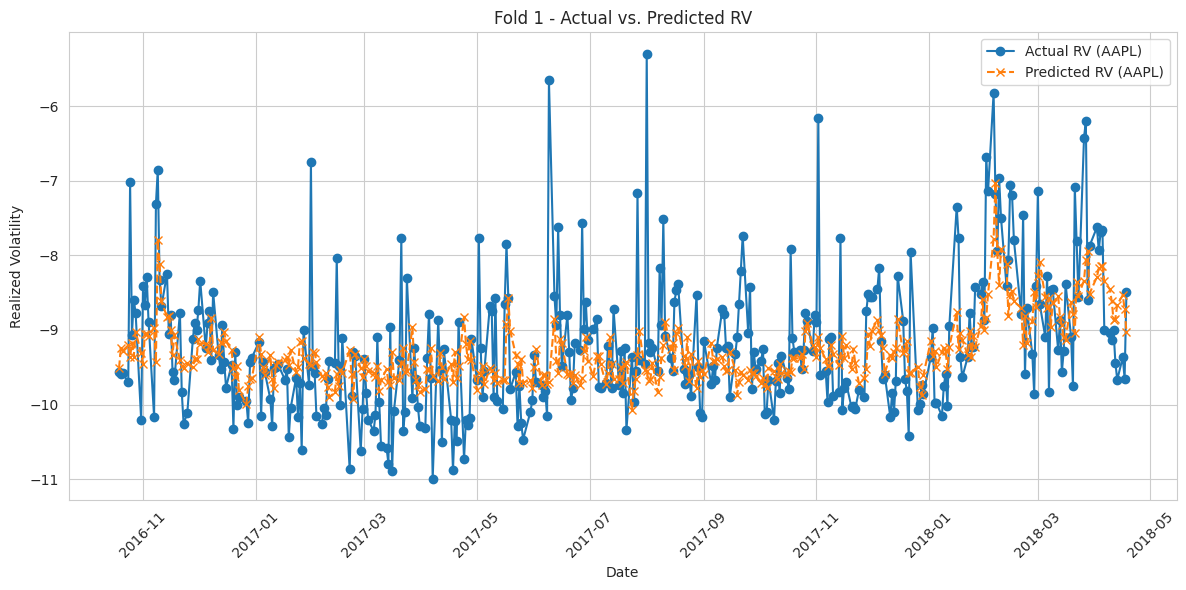

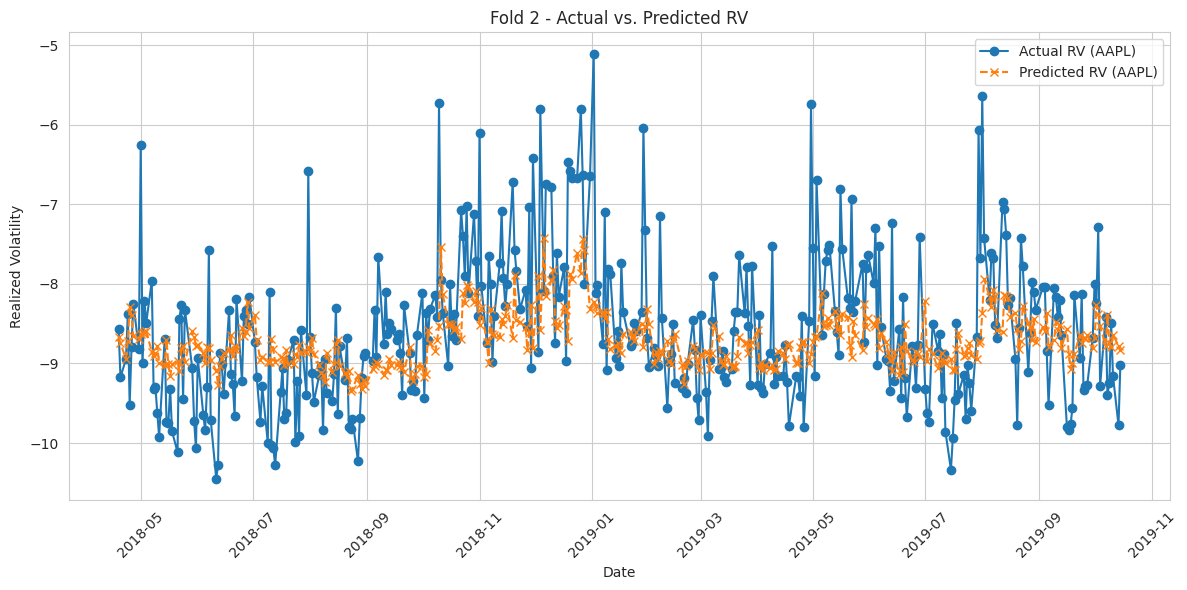

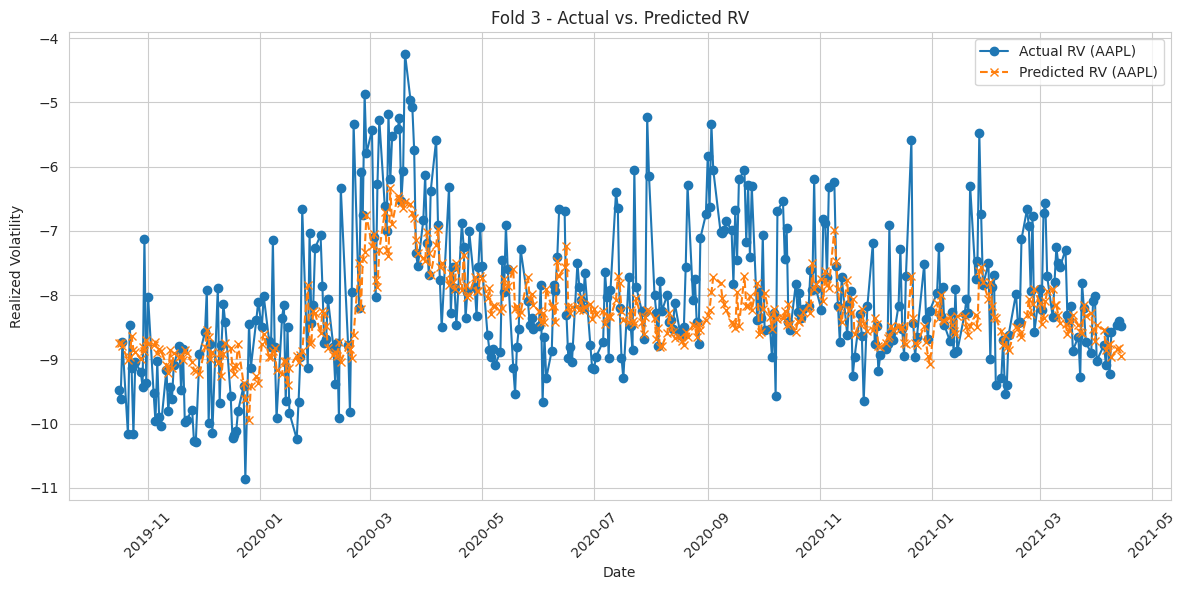

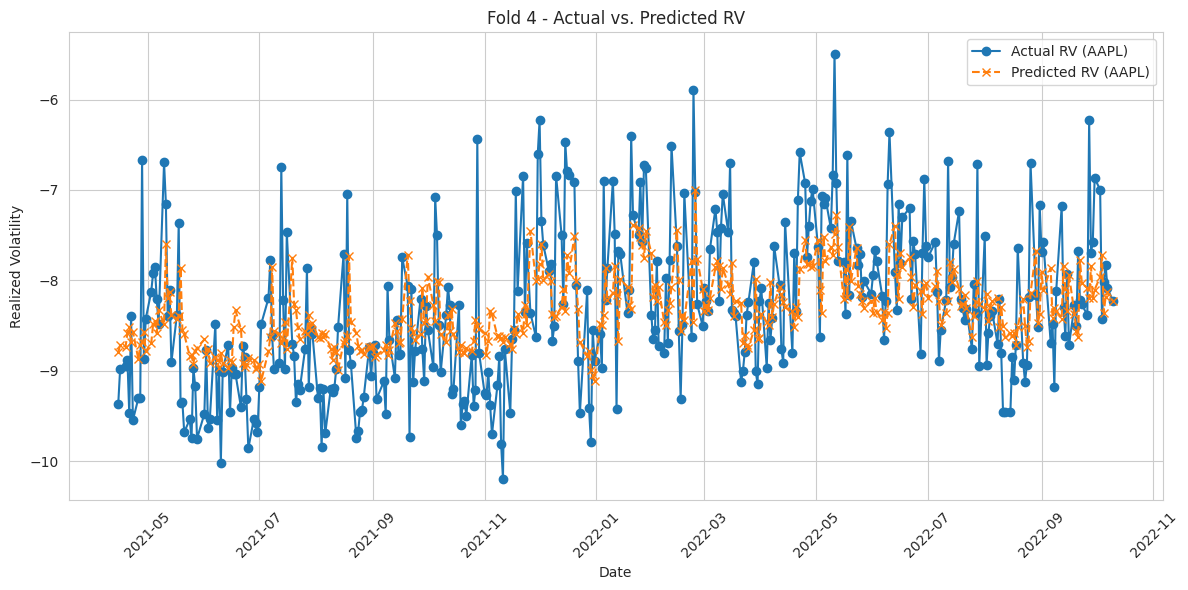

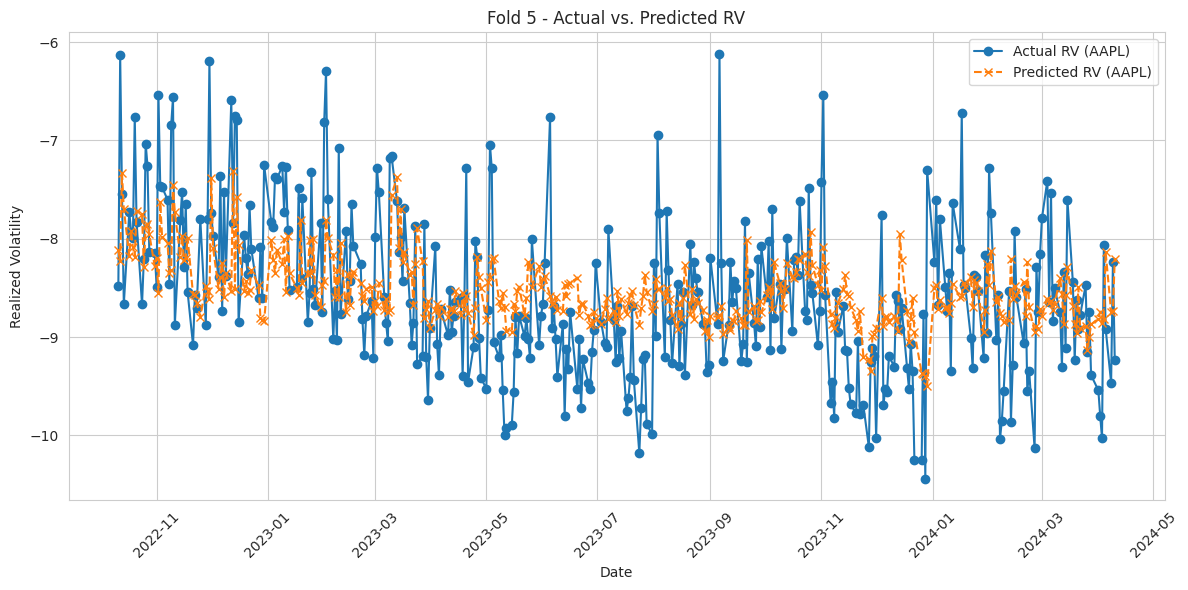

In [8]:
print("\n=== Visualizing Predictions per Ticker ===")
sns.set_style("whitegrid")
for result in all_fold_results:
    fold_num = result['fold']
    val_df_fold = result['val_df']
    unique_tickers = val_df_fold['symbol'].unique()[:1]
    for ticker in unique_tickers:
        ticker_df = val_df_fold[val_df_fold['symbol'] == ticker].sort_values(by='date')
        plt.figure(figsize=(12, 6))
        plt.plot(ticker_df['date'], ticker_df['y_true'], label=f'Actual RV ({ticker})', marker='o', linestyle='-')
        plt.plot(ticker_df['date'], ticker_df['y_pred'], label=f'Predicted RV ({ticker})', marker='x', linestyle='--')
        plt.xlabel("Date")
        plt.ylabel("Realized Volatility")
        plt.title(f"Fold {result['fold']} - Actual vs. Predicted RV")
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [9]:
ticker_r2 = {}
for result in all_fold_results:
    val_df_fold = result['val_df']
    unique_tickers = val_df_fold['symbol'].unique()
    for ticker in unique_tickers:
        ticker_data = val_df_fold[val_df_fold['symbol'] == ticker]
        r2 = r2_score(ticker_data['y_true'], ticker_data['y_pred'])
        if ticker not in ticker_r2:
            ticker_r2[ticker] = []
        ticker_r2[ticker].append(r2)

print("\n=== Average Validation R-squared per Ticker ===")
for ticker, r2_scores in ticker_r2.items():
    print(f"Ticker {ticker}: Average R-squared = {np.mean(r2_scores):.4f}")


=== Average Validation R-squared per Ticker ===
Ticker AAPL: Average R-squared = 0.2401
Ticker ABBV: Average R-squared = 0.0706
Ticker ABT: Average R-squared = 0.0971
Ticker ACN: Average R-squared = 0.1924
Ticker ADBE: Average R-squared = 0.0862
Ticker ADP: Average R-squared = 0.1782
Ticker AMAT: Average R-squared = -0.0675
Ticker AMD: Average R-squared = -0.3006
Ticker AMGN: Average R-squared = 0.1108
Ticker AMT: Average R-squared = 0.1087
Ticker AMZN: Average R-squared = 0.1256
Ticker AVGO: Average R-squared = 0.1610
Ticker AXP: Average R-squared = 0.1743
Ticker BA: Average R-squared = -0.0020
Ticker BAC: Average R-squared = 0.1655
Ticker BKNG: Average R-squared = 0.0961
Ticker BLK: Average R-squared = 0.2611
Ticker BMY: Average R-squared = 0.0454
Ticker BRK.B: Average R-squared = 0.2556
Ticker BSX: Average R-squared = 0.0525
Ticker BX: Average R-squared = 0.1676
Ticker C: Average R-squared = 0.1815
Ticker CAT: Average R-squared = 0.2036
Ticker CB: Average R-squared = 0.1157
Ticker 